# TimeGAN training on SWaT A7 June 2020 (mixed variables)

Este notebook entrena un TimeGAN sobre ventanas multivariadas del dataset SWaT A7 June 2020, usando la misma representación esperada por los detectores de anomalías

Objetivos:
1. Reutilizar exactamente el pipeline de preprocesamiento de los detectores
2. Entrenar TimeGAN sobre ventanas temporales compatibles con reentrenamiento
3. Generar datos sintéticos
4. Postprocesar variables discretas a estados válidos
5. Guardar modelo y datasets sintéticos

In [1]:
import os
import json
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## Reproducibilidad

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = str(SEED)

## Rutas del proyecto

In [3]:
PROJECT_ROOT = Path("..")
CLEAN_DATA_DIR = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan"
TIMEGAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)

SYNTHETIC_DIR = PROJECT_ROOT / "data" / "synthetic"
SYNTHETIC_DIR.mkdir(parents=True, exist_ok=True)

METADATA_DIR = PROJECT_ROOT / "artifacts" / "metadata"
METADATA_DIR.mkdir(parents=True, exist_ok=True)

SCALER_DIR = PROJECT_ROOT / "artifacts" / "scalers"
SCALER_DIR.mkdir(parents=True, exist_ok=True)

print("Clean data dir:", CLEAN_DATA_DIR.resolve())
print("TimeGAN model dir:", TIMEGAN_MODEL_DIR.resolve())
print("Synthetic dir:", SYNTHETIC_DIR.resolve())

Clean data dir: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\clean\SWaT.A7_June2020_clean
TimeGAN model dir: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\timegan
Synthetic dir: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\synthetic


## Cargar configuración de un detector base

In [4]:
detector_config_path = PROJECT_ROOT / "models" / "detectors" / "conv1d_ae" / "config.json"

with open(detector_config_path, "r") as f:
    detector_config = json.load(f)

detector_config

{'model_name': 'conv1d_ae',
 'continuous_cols': ['AIT201.Pv',
  'AIT202.Pv',
  'AIT203.Pv',
  'AIT501.Pv',
  'AIT502.Pv',
  'AIT503.Pv',
  'AIT504.Pv',
  'DPIT301.Pv',
  'FIT101.Pv',
  'FIT201.Pv',
  'FIT301.Pv',
  'FIT401.Pv',
  'FIT501.Pv',
  'FIT502.Pv',
  'FIT503.Pv',
  'FIT504.Pv',
  'FIT601.Pv',
  'LIT101.Pv',
  'LIT301.Pv',
  'LIT401.Pv',
  'PIT501.Pv',
  'PIT502.Pv',
  'PIT503.Pv'],
 'discrete_cols': ['MV101.Status',
  'MV201.Status',
  'MV301.Status',
  'MV302.Status',
  'MV303.Status',
  'MV304.Status',
  'MV501.Status',
  'MV502.Status',
  'MV503.Status',
  'MV504.Status',
  'P101.Status',
  'P201.Status',
  'P203.Status',
  'P205.Status',
  'P301.Status',
  'P401.Status',
  'P501.Status',
  'P601.Status',
  'P602.Status',
  'UV401.Status',
  'P1_STATE',
  'P2_STATE',
  'P3_STATE',
  'P4_STATE',
  'P5_STATE',
  'P6_STATE'],
 'feature_cols': ['AIT201.Pv',
  'AIT202.Pv',
  'AIT203.Pv',
  'AIT501.Pv',
  'AIT502.Pv',
  'AIT503.Pv',
  'AIT504.Pv',
  'DPIT301.Pv',
  'FIT101.Pv',
 

## Extraer parámetros base

In [5]:
continuous_cols = detector_config["continuous_cols"]
discrete_cols = detector_config["discrete_cols"]
feature_cols = detector_config["feature_cols"]

WARMUP = detector_config["warmup"]
WINDOW_SIZE = detector_config["window_size"]
STRIDE = detector_config["stride"]

print("Continuous cols:", len(continuous_cols))
print("Discrete cols:", len(discrete_cols))
print("Feature cols:", len(feature_cols))
print("Warmup:", WARMUP)
print("Window size:", WINDOW_SIZE)
print("Stride:", STRIDE)

Continuous cols: 23
Discrete cols: 26
Feature cols: 49
Warmup: 120
Window size: 60
Stride: 5


## Cargar CSV

In [6]:
file_paths = sorted(CLEAN_DATA_DIR.glob("*.csv"))

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    df = df.sort_values("t_stamp").reset_index(drop=True)
    return df

files = {fp.stem: load_clean_csv(fp) for fp in file_paths}

for name, df in files.items():
    print(name, df.shape)

22June2020_1 (14400, 61)
22June2020_2 (3600, 61)
29June2020_1 (7201, 61)
29June2020_2 (7201, 61)


In [7]:
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
print(f"Número de columnas comunes: {len(common_cols)}")

for name, df in files.items():
    extra = sorted(set(df.columns) - set(common_cols))
    if extra:
        print(f"{name} tiene columnas no comunes: {extra}")

Número de columnas comunes: 61


In [8]:
files = {name: df[common_cols].copy() for name, df in files.items()}

for name in files:
    keep_cols = ["t_stamp"] + feature_cols
    files[name] = files[name][keep_cols].copy()

for name, df in files.items():
    print(name, df.shape)

22June2020_1 (14400, 50)
22June2020_2 (3600, 50)
29June2020_1 (7201, 50)
29June2020_2 (7201, 50)


In [9]:
for name, df in files.items():
    print(name, "missing total:", df.isna().sum().sum())

22June2020_1 missing total: 0
22June2020_2 missing total: 0
29June2020_1 missing total: 0
29June2020_2 missing total: 49


## Warm-up

In [10]:
files = {
    name: df.iloc[WARMUP:].reset_index(drop=True)
    for name, df in files.items()
}

for name, df in files.items():
    print(name, df.shape)

22June2020_1 (14280, 50)
22June2020_2 (3480, 50)
29June2020_1 (7081, 50)
29June2020_2 (7081, 50)


## Partición temporal

In [11]:
def temporal_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df   = df.iloc[train_end:val_end].copy()
    test_df  = df.iloc[val_end:].copy()

    return train_df, val_df, test_df

In [12]:
train_parts = []
val_parts = []
test_parts = []

for i, (name, df_i) in enumerate(files.items()):
    feature_df = df_i[feature_cols].copy()
    train_i, val_i, test_i = temporal_split(feature_df, train_ratio=0.6, val_ratio=0.2)

    train_parts.append(train_i)
    val_parts.append(val_i)
    test_parts.append(test_i)

    print(f"{name}: train={train_i.shape}, val={val_i.shape}, test={test_i.shape}")

train_df = pd.concat(train_parts, axis=0).reset_index(drop=True)
val_df   = pd.concat(val_parts, axis=0).reset_index(drop=True)
test_df  = pd.concat(test_parts, axis=0).reset_index(drop=True)

print("\nGlobal shapes:")
print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

22June2020_1: train=(8568, 49), val=(2856, 49), test=(2856, 49)
22June2020_2: train=(2088, 49), val=(696, 49), test=(696, 49)
29June2020_1: train=(4248, 49), val=(1416, 49), test=(1417, 49)
29June2020_2: train=(4248, 49), val=(1416, 49), test=(1417, 49)

Global shapes:
Train: (19152, 49)
Val:   (6384, 49)
Test:  (6386, 49)


## Escalado de continuas

In [13]:
scaler_cont = StandardScaler()

train_cont = pd.DataFrame(
    scaler_cont.fit_transform(train_df[continuous_cols]),
    columns=continuous_cols
)

val_cont = pd.DataFrame(
    scaler_cont.transform(val_df[continuous_cols]),
    columns=continuous_cols
)

test_cont = pd.DataFrame(
    scaler_cont.transform(test_df[continuous_cols]),
    columns=continuous_cols
)

## Escalado acotado de discretas

In [14]:
train_disc = train_df[discrete_cols].copy()
val_disc   = val_df[discrete_cols].copy()
test_disc  = test_df[discrete_cols].copy()

disc_max = train_disc.max().replace(0, 1)

train_disc_scaled = train_disc / disc_max
val_disc_scaled   = val_disc / disc_max
test_disc_scaled  = test_disc / disc_max

In [15]:
valid_discrete_values = {
    col: sorted(train_df[col].dropna().unique().tolist())
    for col in discrete_cols
}

valid_discrete_values

{'MV101.Status': [0.0, 1.0, 2.0],
 'MV201.Status': [0.0, 1.0, 2.0],
 'MV301.Status': [0.0, 1.0, 2.0],
 'MV302.Status': [0.0, 1.0, 2.0],
 'MV303.Status': [0.0, 1.0, 2.0],
 'MV304.Status': [0.0, 1.0, 2.0],
 'MV501.Status': [0.0, 1.0, 2.0],
 'MV502.Status': [0.0, 1.0, 2.0],
 'MV503.Status': [0.0, 1.0, 2.0],
 'MV504.Status': [0.0, 1.0, 2.0],
 'P101.Status': [1.0, 2.0],
 'P201.Status': [1.0, 2.0],
 'P203.Status': [1.0, 2.0],
 'P205.Status': [1.0, 2.0],
 'P301.Status': [1.0, 2.0],
 'P401.Status': [1.0, 2.0],
 'P501.Status': [1.0, 2.0],
 'P601.Status': [1.0, 2.0],
 'P602.Status': [1.0, 2.0],
 'UV401.Status': [1.0, 2.0],
 'P1_STATE': [1.0, 2.0, 3.0],
 'P2_STATE': [1.0, 2.0],
 'P3_STATE': [1.0,
  2.0,
  4.0,
  5.0,
  6.0,
  7.0,
  9.0,
  10.0,
  12.0,
  13.0,
  14.0,
  15.0,
  16.0,
  99.0],
 'P4_STATE': [1.0, 2.0, 3.0, 4.0],
 'P5_STATE': [1.0,
  3.0,
  4.0,
  5.0,
  6.0,
  8.0,
  9.0,
  10.0,
  11.0,
  12.0,
  15.0,
  16.0,
  17.0,
  18.0,
  19.0,
  21.0],
 'P6_STATE': [1.0, 2.0]}

## Concatenar

In [16]:
train_scaled = pd.concat(
    [train_cont.reset_index(drop=True), train_disc_scaled.reset_index(drop=True)],
    axis=1
)[continuous_cols + discrete_cols]

val_scaled = pd.concat(
    [val_cont.reset_index(drop=True), val_disc_scaled.reset_index(drop=True)],
    axis=1
)[continuous_cols + discrete_cols]

test_scaled = pd.concat(
    [test_cont.reset_index(drop=True), test_disc_scaled.reset_index(drop=True)],
    axis=1
)[continuous_cols + discrete_cols]

In [17]:
print("Continuous stats (train):")
print(train_scaled[continuous_cols].describe().loc[["mean", "std"]])

print("\nDiscrete stats (train):")
print(train_scaled[discrete_cols].describe().loc[["min", "max"]])

print("\nAny NaNs?")
print(train_scaled.isna().sum().sum())

Continuous stats (train):
         AIT201.Pv     AIT202.Pv     AIT203.Pv     AIT501.Pv     AIT502.Pv  \
mean -4.748824e-17 -1.567112e-15  1.234694e-15 -5.698588e-15 -4.748824e-17   
std   1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00   

         AIT503.Pv     AIT504.Pv    DPIT301.Pv     FIT101.Pv     FIT201.Pv  \
mean  2.374412e-17 -5.936030e-17 -1.068485e-16  2.374412e-17  9.497647e-17   
std   1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00   

      ...     FIT502.Pv     FIT503.Pv     FIT504.Pv     FIT601.Pv  \
mean  ... -7.123235e-17  5.936030e-17 -3.710018e-18 -2.968015e-18   
std   ...  1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00   

         LIT101.Pv     LIT301.Pv     LIT401.Pv     PIT501.Pv     PIT502.Pv  \
mean -1.424647e-16 -9.497647e-17  3.799059e-16 -2.136971e-16 -2.374412e-16   
std   1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00   

      PIT503.Pv  
mean   0.000000  
std    1.000026  

[2 row

## Crear ventanas

In [18]:
def create_windows(data, window_size=60, stride=5):
    windows = []
    for i in range(0, len(data) - window_size + 1, stride):
        windows.append(data[i:i+window_size])
    return np.array(windows)

In [19]:
train_windows = create_windows(train_scaled.values, window_size=WINDOW_SIZE, stride=STRIDE)
val_windows   = create_windows(val_scaled.values, window_size=WINDOW_SIZE, stride=STRIDE)
test_windows  = create_windows(test_scaled.values, window_size=WINDOW_SIZE, stride=STRIDE)

print("Train windows:", train_windows.shape)
print("Val windows:  ", val_windows.shape)
print("Test windows: ", test_windows.shape)

Train windows: (3819, 60, 49)
Val windows:   (1265, 60, 49)
Test windows:  (1266, 60, 49)


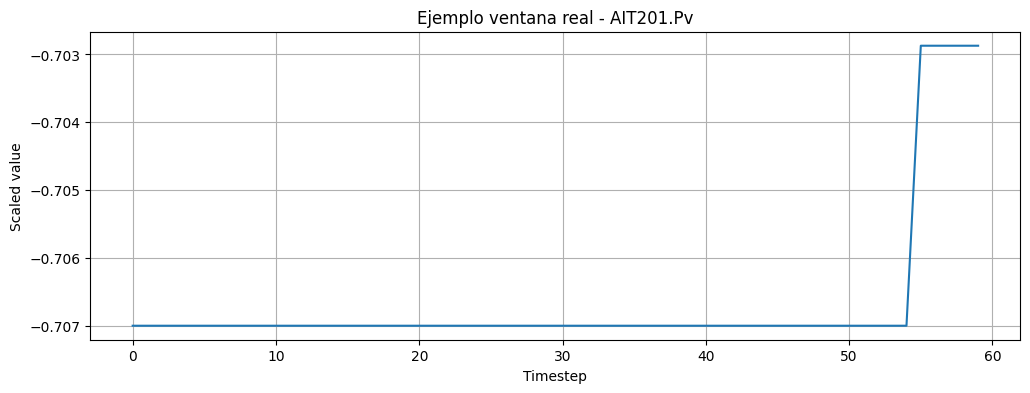

In [20]:
plt.figure(figsize=(12, 4))
plt.plot(train_windows[0][:, 0])  # primera variable continua
plt.title(f"Ejemplo ventana real - {continuous_cols[0]}")
plt.xlabel("Timestep")
plt.ylabel("Scaled value")
plt.grid(True)
plt.show()

## TensorDataset para TimeGAN

In [21]:
train_tensor = torch.tensor(train_windows, dtype=torch.float32)
train_dataset = TensorDataset(train_tensor)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

print(train_tensor.shape)

torch.Size([3819, 60, 49])


## Implementación de TimeGAN

### Hiperparámetros

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seq_len = train_windows.shape[1]
feature_dim = train_windows.shape[2]
hidden_dim = 64
latent_dim = 32
num_layers = 2
batch_size = 128
epochs_embedder = 50
epochs_supervisor = 50
epochs_joint = 100
gamma = 1

print("Device:", device)
print("seq_len:", seq_len)
print("feature_dim:", feature_dim)

Device: cpu
seq_len: 60
feature_dim: 49


### Módulos TimeGAN

In [23]:
class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_layers):
        super().__init__()
        self.rnn = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, latent_dim)
        self.act = nn.Sigmoid()

    def forward(self, x):
        h, _ = self.rnn(x)
        h = self.act(self.fc(h))
        return h


class Recovery(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn = nn.LSTM(latent_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, h):
        x_tilde, _ = self.rnn(h)
        x_tilde = self.fc(x_tilde)
        return x_tilde


class Generator(nn.Module):
    def __init__(self, z_dim, hidden_dim, latent_dim, num_layers):
        super().__init__()
        self.rnn = nn.LSTM(z_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, latent_dim)
        self.act = nn.Sigmoid()

    def forward(self, z):
        e_hat, _ = self.rnn(z)
        e_hat = self.act(self.fc(e_hat))
        return e_hat


class Supervisor(nn.Module):
    def __init__(self, latent_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.LSTM(latent_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, latent_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        h_hat, _ = self.rnn(h)
        h_hat = self.act(self.fc(h_hat))
        return h_hat


class Discriminator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.LSTM(latent_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        y_hat, _ = self.rnn(h)
        y_hat = self.fc(y_hat[:, -1, :])  # clasificación a nivel secuencia
        return y_hat

In [24]:
embedder = Embedder(feature_dim, hidden_dim, latent_dim, num_layers).to(device)
recovery = Recovery(latent_dim, hidden_dim, feature_dim, num_layers).to(device)
generator = Generator(latent_dim, hidden_dim, latent_dim, num_layers).to(device)
supervisor = Supervisor(latent_dim, hidden_dim, num_layers - 1).to(device)
discriminator = Discriminator(latent_dim, hidden_dim, num_layers).to(device)

### Optimizadores y pérdidas

In [25]:
mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = optim.Adam(list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3)
g_optimizer = optim.Adam(list(generator.parameters()) + list(supervisor.parameters()), lr=1e-3)
d_optimizer = optim.Adam(discriminator.parameters(), lr=1e-3)

In [26]:
def random_generator(batch_size, seq_len, z_dim, device):
    return torch.rand((batch_size, seq_len, z_dim), device=device)

def moment_loss(y_true, y_pred):
    y_true_mean, y_true_var = torch.mean(y_true, dim=0), torch.var(y_true, dim=0)
    y_pred_mean, y_pred_var = torch.mean(y_pred, dim=0), torch.var(y_pred, dim=0)

    mean_loss = torch.mean(torch.abs(y_true_mean - y_pred_mean))
    var_loss = torch.mean(torch.abs(torch.sqrt(y_true_var + 1e-6) - torch.sqrt(y_pred_var + 1e-6)))
    return mean_loss + var_loss

### Fase 1: preentrenar embedder y recovery

In [27]:
embedder_history = []

for epoch in range(epochs_embedder):
    epoch_loss = 0

    for batch in train_loader:
        x = batch[0].to(device)

        e_optimizer.zero_grad()

        h = embedder(x)
        x_tilde = recovery(h)

        loss_e = mse_loss(x_tilde, x)
        loss_e.backward()
        e_optimizer.step()

        epoch_loss += loss_e.item()

    epoch_loss /= len(train_loader)
    embedder_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"[Embedder] Epoch {epoch+1}/{epochs_embedder} - Loss: {epoch_loss:.6f}")

[Embedder] Epoch 10/50 - Loss: 0.175642
[Embedder] Epoch 20/50 - Loss: 0.120287
[Embedder] Epoch 30/50 - Loss: 0.073414
[Embedder] Epoch 40/50 - Loss: 0.055325
[Embedder] Epoch 50/50 - Loss: 0.044924


### Fase 2: preentrenar supervisor

In [28]:
supervisor_history = []

for epoch in range(epochs_supervisor):
    epoch_loss = 0

    for batch in train_loader:
        x = batch[0].to(device)

        g_optimizer.zero_grad()

        h = embedder(x).detach()
        h_hat_supervise = supervisor(h)

        loss_s = mse_loss(h[:, 1:, :], h_hat_supervise[:, :-1, :])
        loss_s.backward()
        g_optimizer.step()

        epoch_loss += loss_s.item()

    epoch_loss /= len(train_loader)
    supervisor_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"[Supervisor] Epoch {epoch+1}/{epochs_supervisor} - Loss: {epoch_loss:.6f}")

[Supervisor] Epoch 10/50 - Loss: 0.002349
[Supervisor] Epoch 20/50 - Loss: 0.001193
[Supervisor] Epoch 30/50 - Loss: 0.000736
[Supervisor] Epoch 40/50 - Loss: 0.000483
[Supervisor] Epoch 50/50 - Loss: 0.000359


### Fase 3: entrenamiento conjunto

In [30]:
joint_g_history = []
joint_d_history = []
joint_e_history = []

for epoch in range(epochs_joint):
    g_epoch_loss = 0
    d_epoch_loss = 0
    e_epoch_loss = 0

    for batch in train_loader:
        x = batch[0].to(device)
        batch_size_curr = x.shape[0]

        # ---------------------
        # Train Generator + Supervisor
        # ---------------------
        for _ in range(2):
            g_optimizer.zero_grad()

            # Real embedding (detach para que no arrastre gradientes al embedder aquí)
            h = embedder(x).detach()

            # Synthetic latent
            z = random_generator(batch_size_curr, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)

            # Synthetic recovered sequence
            x_hat = recovery(h_hat)

            # Adversarial loss
            y_fake = discriminator(h_hat)
            g_loss_u = bce_loss(y_fake, torch.ones_like(y_fake))

            y_fake_e = discriminator(e_hat)
            g_loss_u_e = bce_loss(y_fake_e, torch.ones_like(y_fake_e))

            # Supervised loss
            h_supervise = supervisor(h)
            g_loss_s = mse_loss(h[:, 1:, :], h_supervise[:, :-1, :])

            # Moment matching loss
            g_loss_v = moment_loss(x, x_hat)

            g_loss = (
                g_loss_u
                + gamma * g_loss_u_e
                + 100 * torch.sqrt(g_loss_s + 1e-8)
                + 100 * g_loss_v
            )

            g_loss.backward()
            g_optimizer.step()

            # ---------------------
            # Train Embedder + Recovery refinement
            # ---------------------
            e_optimizer.zero_grad()

            h_e = embedder(x)
            x_tilde = recovery(h_e)
            h_supervise_e = supervisor(h_e)

            e_loss_t0 = mse_loss(x_tilde, x)
            e_loss0 = 10 * torch.sqrt(e_loss_t0 + 1e-8)

            # recalcular supervisada para este paso
            e_loss_s = mse_loss(h_e[:, 1:, :], h_supervise_e[:, :-1, :])

            e_loss = e_loss0 + 0.1 * e_loss_s

            e_loss.backward()
            e_optimizer.step()

        # ---------------------
        # Train Discriminator
        # ---------------------
        d_optimizer.zero_grad()

        with torch.no_grad():
            h = embedder(x)
            z = random_generator(batch_size_curr, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)

        y_real = discriminator(h)
        y_fake = discriminator(h_hat)
        y_fake_e = discriminator(e_hat)

        d_loss_real = bce_loss(y_real, torch.ones_like(y_real))
        d_loss_fake = bce_loss(y_fake, torch.zeros_like(y_fake))
        d_loss_fake_e = bce_loss(y_fake_e, torch.zeros_like(y_fake_e))

        d_loss = d_loss_real + d_loss_fake + gamma * d_loss_fake_e

        if d_loss.item() > 0.15:
            d_loss.backward()
            d_optimizer.step()

        g_epoch_loss += g_loss.item()
        d_epoch_loss += d_loss.item()
        e_epoch_loss += e_loss.item()

    g_epoch_loss /= len(train_loader)
    d_epoch_loss /= len(train_loader)
    e_epoch_loss /= len(train_loader)

    joint_g_history.append(g_epoch_loss)
    joint_d_history.append(d_epoch_loss)
    joint_e_history.append(e_epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"[Joint] Epoch {epoch+1}/{epochs_joint} | "
            f"G: {g_epoch_loss:.6f} | D: {d_epoch_loss:.6f} | E: {e_epoch_loss:.6f}"
        )

[Joint] Epoch 10/100 | G: 81.222505 | D: 1.829992 | E: 2.330487
[Joint] Epoch 20/100 | G: 27.194775 | D: 1.883714 | E: 1.637911
[Joint] Epoch 30/100 | G: 31.832840 | D: 1.714548 | E: 1.414287
[Joint] Epoch 40/100 | G: 30.736888 | D: 1.827685 | E: 1.406116
[Joint] Epoch 50/100 | G: 79.052379 | D: 1.227874 | E: 1.305235
[Joint] Epoch 60/100 | G: 70.379286 | D: 0.997861 | E: 1.144751
[Joint] Epoch 70/100 | G: 102.759517 | D: 0.752559 | E: 1.528521
[Joint] Epoch 80/100 | G: 86.026623 | D: 0.566012 | E: 1.073039
[Joint] Epoch 90/100 | G: 103.746697 | D: 1.535517 | E: 0.968965
[Joint] Epoch 100/100 | G: 92.889444 | D: 0.124914 | E: 0.922728


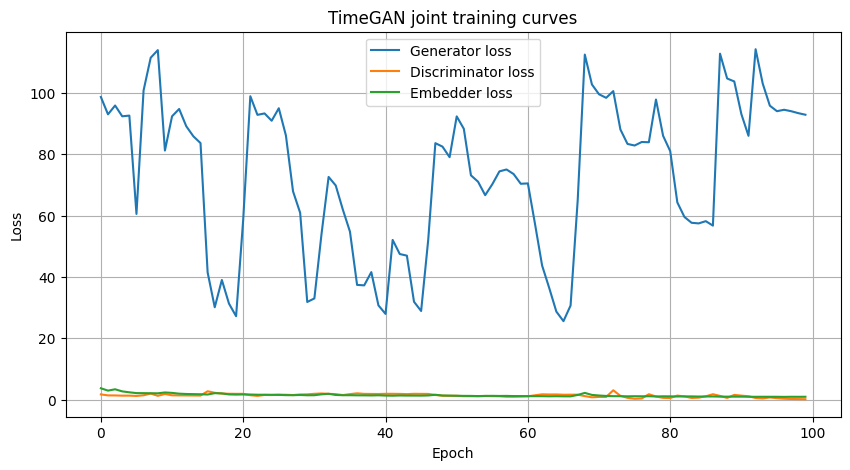

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(joint_g_history, label="Generator loss")
plt.plot(joint_d_history, label="Discriminator loss")
plt.plot(joint_e_history, label="Embedder loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TimeGAN joint training curves")
plt.grid(True)
plt.legend()
plt.show()

### Generar secuencias sintéticas

In [32]:
def generate_synthetic_data(n_samples):
    generator.eval()
    supervisor.eval()
    recovery.eval()

    synthetic_data = []

    with torch.no_grad():
        remaining = n_samples
        while remaining > 0:
            batch_n = min(256, remaining)
            z = random_generator(batch_n, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)
            x_hat = recovery(h_hat)

            synthetic_data.append(x_hat.cpu().numpy())
            remaining -= batch_n

    synthetic_data = np.concatenate(synthetic_data, axis=0)
    return synthetic_data

synthetic_windows_scaled = generate_synthetic_data(train_windows.shape[0])
print("Synthetic windows scaled:", synthetic_windows_scaled.shape)

Synthetic windows scaled: (3819, 60, 49)


In [33]:
continuous_idx = [feature_cols.index(c) for c in continuous_cols]
discrete_idx = [feature_cols.index(c) for c in discrete_cols]
disc_max_array = disc_max[discrete_cols].values.astype(float)

In [34]:
def nearest_valid_value(value, valid_values):
    return min(valid_values, key=lambda x: abs(x - value))

def postprocess_synthetic_windows(synth_scaled):
    synth_post = synth_scaled.copy()

    # 1. Continuas: invertir StandardScaler
    cont_block = synth_post[:, :, continuous_idx]
    cont_2d = cont_block.reshape(-1, len(continuous_cols))
    cont_2d = scaler_cont.inverse_transform(cont_2d)
    cont_block_inv = cont_2d.reshape(synth_post.shape[0], synth_post.shape[1], len(continuous_cols))
    synth_post[:, :, continuous_idx] = cont_block_inv

    # 2. Discretas: desescalar y proyectar a valores válidos
    disc_block = synth_post[:, :, discrete_idx]
    disc_block = disc_block * disc_max_array.reshape(1, 1, -1)

    for j, col in enumerate(discrete_cols):
        valid_vals = valid_discrete_values[col]
        for i in range(disc_block.shape[0]):
            for t in range(disc_block.shape[1]):
                disc_block[i, t, j] = nearest_valid_value(disc_block[i, t, j], valid_vals)

    synth_post[:, :, discrete_idx] = disc_block
    return synth_post

synthetic_windows_post = postprocess_synthetic_windows(synthetic_windows_scaled)
print("Synthetic windows postprocessed:", synthetic_windows_post.shape)

Synthetic windows postprocessed: (3819, 60, 49)


### Verificar rangos sintéticos

In [35]:
print("Synthetic scaled min/max:", synthetic_windows_scaled.min(), synthetic_windows_scaled.max())
print("Synthetic postprocessed min/max:", synthetic_windows_post.min(), synthetic_windows_post.max())

Synthetic scaled min/max: -3.9712625 11.464566
Synthetic postprocessed min/max: -2.796412 1038.615


### Real vs sintético, feature continua

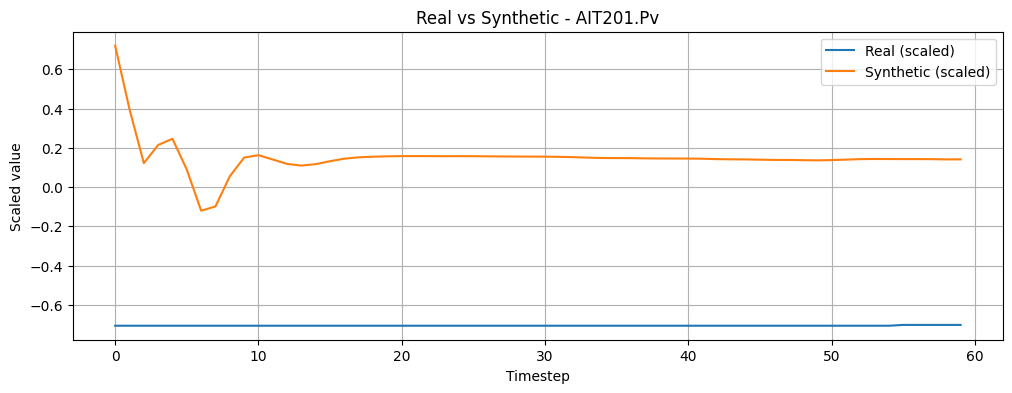

In [36]:
col = continuous_cols[0]
col_idx = feature_cols.index(col)

plt.figure(figsize=(12, 4))
plt.plot(train_windows[0][:, col_idx], label="Real (scaled)")
plt.plot(synthetic_windows_scaled[0][:, col_idx], label="Synthetic (scaled)")
plt.title(f"Real vs Synthetic - {col}")
plt.xlabel("Timestep")
plt.ylabel("Scaled value")
plt.grid(True)
plt.legend()
plt.show()

### Real vs sintético, feature discreta postprocesada

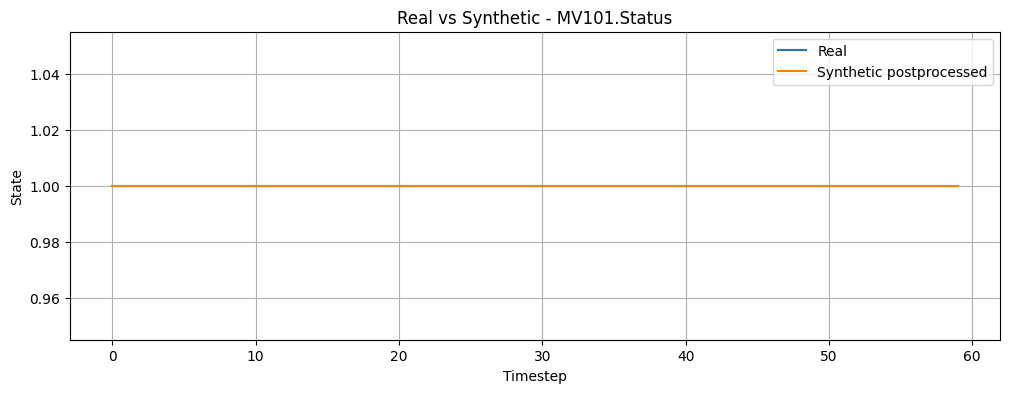

In [37]:
col = discrete_cols[0]
col_idx = feature_cols.index(col)

plt.figure(figsize=(12, 4))
plt.plot(train_df[col].iloc[:WINDOW_SIZE].values, label="Real")
plt.plot(synthetic_windows_post[0][:, col_idx], label="Synthetic postprocessed")
plt.title(f"Real vs Synthetic - {col}")
plt.xlabel("Timestep")
plt.ylabel("State")
plt.grid(True)
plt.legend()
plt.show()

### PCA real vs sintético (solo para visualización comparativa)

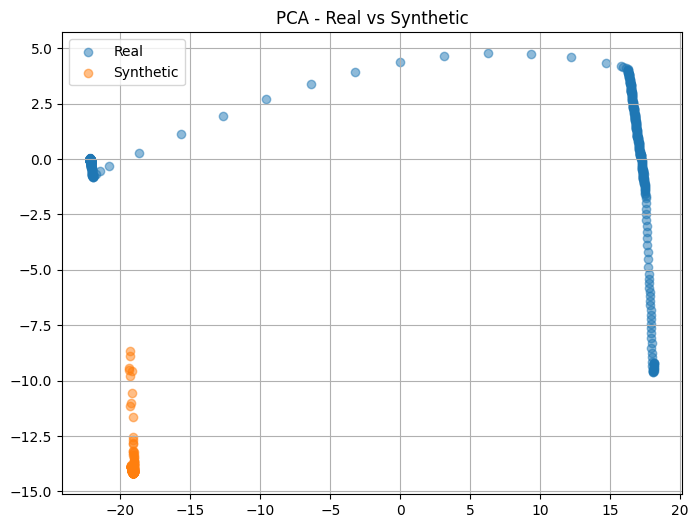

In [38]:
n_plot = min(500, train_windows.shape[0], synthetic_windows_scaled.shape[0])

real_flat = train_windows[:n_plot].reshape(n_plot, -1)
synth_flat = synthetic_windows_scaled[:n_plot].reshape(n_plot, -1)

pca = PCA(n_components=2, random_state=SEED)
pca_real = pca.fit_transform(real_flat)
pca_synth = pca.transform(synth_flat)

plt.figure(figsize=(8, 6))
plt.scatter(pca_real[:, 0], pca_real[:, 1], alpha=0.5, label="Real")
plt.scatter(pca_synth[:, 0], pca_synth[:, 1], alpha=0.5, label="Synthetic")
plt.title("PCA - Real vs Synthetic")
plt.legend()
plt.grid(True)
plt.show()

### t-SNE real vs sintético

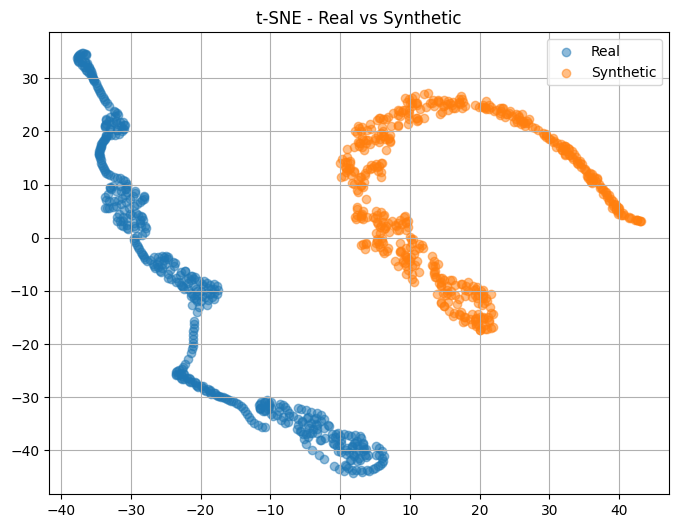

In [39]:
combined = np.concatenate([real_flat, synth_flat], axis=0)
labels = np.array(["Real"] * n_plot + ["Synthetic"] * n_plot)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
tsne_results = tsne.fit_transform(combined)

plt.figure(figsize=(8, 6))
for lab in ["Real", "Synthetic"]:
    idx = labels == lab
    plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1], alpha=0.5, label=lab)

plt.title("t-SNE - Real vs Synthetic")
plt.legend()
plt.grid(True)
plt.show()

### Guardar modelo TimeGAN

In [40]:
timegan_state = {
    "embedder": embedder.state_dict(),
    "recovery": recovery.state_dict(),
    "generator": generator.state_dict(),
    "supervisor": supervisor.state_dict(),
    "discriminator": discriminator.state_dict(),
}

torch.save(timegan_state, TIMEGAN_MODEL_DIR / "timegan_state.pt")
print("TimeGAN state saved.")

TimeGAN state saved.


### Guardar artefactos

In [41]:
joblib.dump(scaler_cont, SCALER_DIR / "timegan_scaler_cont.pkl")
joblib.dump(disc_max, SCALER_DIR / "timegan_disc_max.pkl")

with open(METADATA_DIR / "timegan_valid_discrete_values.json", "w") as f:
    json.dump(valid_discrete_values, f, indent=4)

timegan_config = {
    "seed": SEED,
    "continuous_cols": continuous_cols,
    "discrete_cols": discrete_cols,
    "feature_cols": feature_cols,
    "warmup": WARMUP,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "seq_len": seq_len,
    "feature_dim": feature_dim,
    "hidden_dim": hidden_dim,
    "latent_dim": latent_dim,
    "num_layers": num_layers,
    "epochs_embedder": epochs_embedder,
    "epochs_supervisor": epochs_supervisor,
    "epochs_joint": epochs_joint
}

with open(TIMEGAN_MODEL_DIR / "config.json", "w") as f:
    json.dump(timegan_config, f, indent=4)

print("TimeGAN config and metadata saved.")

TimeGAN config and metadata saved.


### Guardar ventanas sintéticas

In [42]:
np.save(SYNTHETIC_DIR / "timegan_synthetic_windows_scaled.npy", synthetic_windows_scaled)
np.save(SYNTHETIC_DIR / "timegan_synthetic_windows_postprocessed.npy", synthetic_windows_post)

np.save(SYNTHETIC_DIR / "timegan_train_windows_real.npy", train_windows)
np.save(SYNTHETIC_DIR / "timegan_val_windows_real.npy", val_windows)
np.save(SYNTHETIC_DIR / "timegan_test_windows_real.npy", test_windows)

print("Synthetic and real window arrays saved.")

Synthetic and real window arrays saved.


### Resumen

In [43]:
training_history_df = pd.DataFrame({
    "epoch": np.arange(1, len(joint_g_history) + 1),
    "generator_loss": joint_g_history,
    "discriminator_loss": joint_d_history,
    "embedder_loss": joint_e_history
})

training_history_df.to_csv(TIMEGAN_MODEL_DIR / "training_history.csv", index=False)
training_history_df.head()

,epoch,generator_loss,discriminator_loss,embedder_loss
0,1,98.679814,1.694619,3.695586
1,2,93.025329,1.377437,2.933258
2,3,95.899094,1.357714,3.363457
3,4,92.381565,1.286943,2.683236
4,5,92.607063,1.291297,2.377794
